In [3]:
import os

dataset_path = '/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/dataset'

os.listdir(dataset_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/dataset'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Starting the Pre Processing Stage

We will be applying CLAHE


CLAHE = Contrast Limited Adaptive Histogram Equalization

It:

Enhances local contrast. </br>
Makes cell boundaries/nucleus clearer. </br>
Avoids over-amplifying noise.

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm


# Setting up paths

base_path = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/dataset"

train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

output_base = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/clahe_dataset"

output_train = os.path.join(output_base, "train")
output_test = os.path.join(output_base, "test")

Using the same CLAHE Parameters from the Research Paper
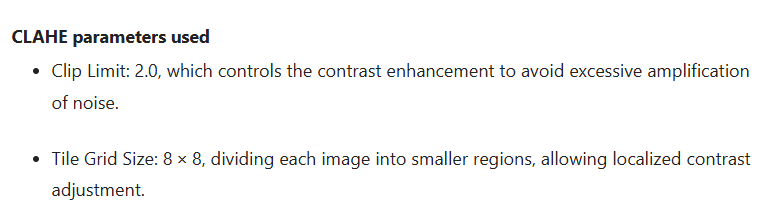

In [ ]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)



# CLAHE Function

def apply_clahe(input_folder, output_folder):

    classes = os.listdir(input_folder)

    for cls in classes:

        input_cls_path = os.path.join(input_folder, cls)
        output_cls_path = os.path.join(output_folder, cls)

        os.makedirs(output_cls_path, exist_ok=True)

        images = os.listdir(input_cls_path)

        for img_name in tqdm(images):

            img_path = os.path.join(input_cls_path, img_name)

            # Read image
            img = cv2.imread(img_path)

            # Convert BGR → LAB
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

            l, a, b = cv2.split(lab)

            # Apply CLAHE on L channel
            cl = clahe.apply(l)

            merged = cv2.merge((cl, a, b))

            # Convert back to RGB
            final_img = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

            # Save image
            save_path = os.path.join(output_cls_path, img_name)

            cv2.imwrite(save_path, final_img)


# Applying


apply_clahe(train_path, output_train)
apply_clahe(test_path, output_test)


100%|██████████| 200/200 [00:10<00:00, 18.57it/s]


# RESIZED for ALEXNet

In [ ]:
import os
import cv2
from tqdm import tqdm


# Input Paths (CLAHE dataset)

input_train = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/clahe_dataset/train"

input_test = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/clahe_dataset/test"


# Output Paths (NEW resized dataset)

output_base = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/resized_dataset"

output_train = os.path.join(output_base, "train")
output_test = os.path.join(output_base, "test")


# Resize Function

def resize_images(input_folder, output_folder, size=(227, 227)):

    classes = os.listdir(input_folder)

    for cls in classes:

        input_cls_path = os.path.join(input_folder, cls)
        output_cls_path = os.path.join(output_folder, cls)

        os.makedirs(output_cls_path, exist_ok=True)

        images = os.listdir(input_cls_path)

        for img_name in tqdm(images):

            img_path = os.path.join(input_cls_path, img_name)

            # Read image
            img = cv2.imread(img_path)

            # Resize image
            resized_img = cv2.resize(
                img,
                size,
                interpolation=cv2.INTER_AREA
            )

            # Save resized image
            save_path = os.path.join(output_cls_path, img_name)

            cv2.imwrite(save_path, resized_img)


# Apply resizing

resize_images(input_train, output_train)
resize_images(input_test, output_test)

100%|██████████| 300/300 [00:12<00:00, 24.96it/s]


# Resized for VGG16

In [ ]:
import os
import cv2
from tqdm import tqdm


# Input Paths (CLAHE dataset)

input_train = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/clahe_dataset/train"

input_test = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/clahe_dataset/test"


# Output Paths (NEW resized dataset)

output_base = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/resized_dataset_VGG16"

output_train = os.path.join(output_base, "train")
output_test = os.path.join(output_base, "test")


# Resize Function

def resize_images(input_folder, output_folder, size=(224, 224)):

    classes = os.listdir(input_folder)

    for cls in classes:

        input_cls_path = os.path.join(input_folder, cls)
        output_cls_path = os.path.join(output_folder, cls)

        os.makedirs(output_cls_path, exist_ok=True)

        images = os.listdir(input_cls_path)

        for img_name in tqdm(images):

            img_path = os.path.join(input_cls_path, img_name)

            # Read image
            img = cv2.imread(img_path)

            # Resize image
            resized_img = cv2.resize(
                img,
                size,
                interpolation=cv2.INTER_AREA
            )

            # Save resized image
            save_path = os.path.join(output_cls_path, img_name)

            cv2.imwrite(save_path, resized_img)


# Apply resizing

resize_images(input_train, output_train)
resize_images(input_test, output_test)

100%|██████████| 300/300 [00:09<00:00, 30.73it/s]


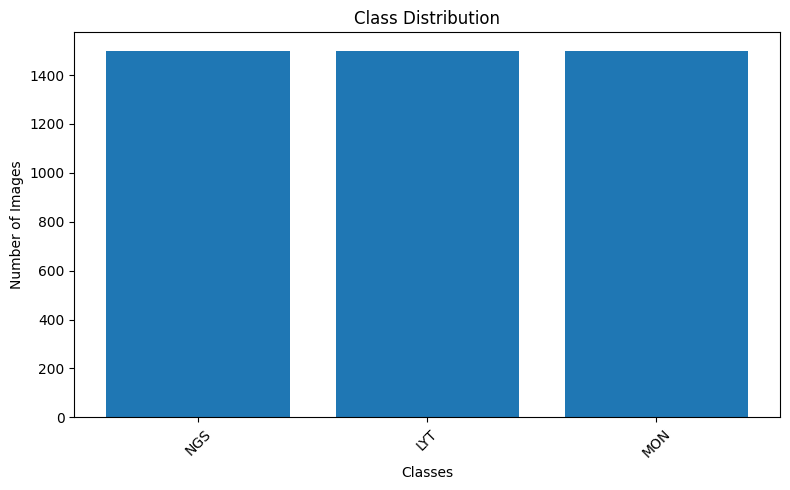

In [5]:
import os
import matplotlib.pyplot as plt

train_path = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/dataset/train"

classes = os.listdir(train_path)
counts = [len(os.listdir(os.path.join(train_path, cls))) for cls in classes]

plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Figure_4_1_Class_Distribution.png")
plt.show()

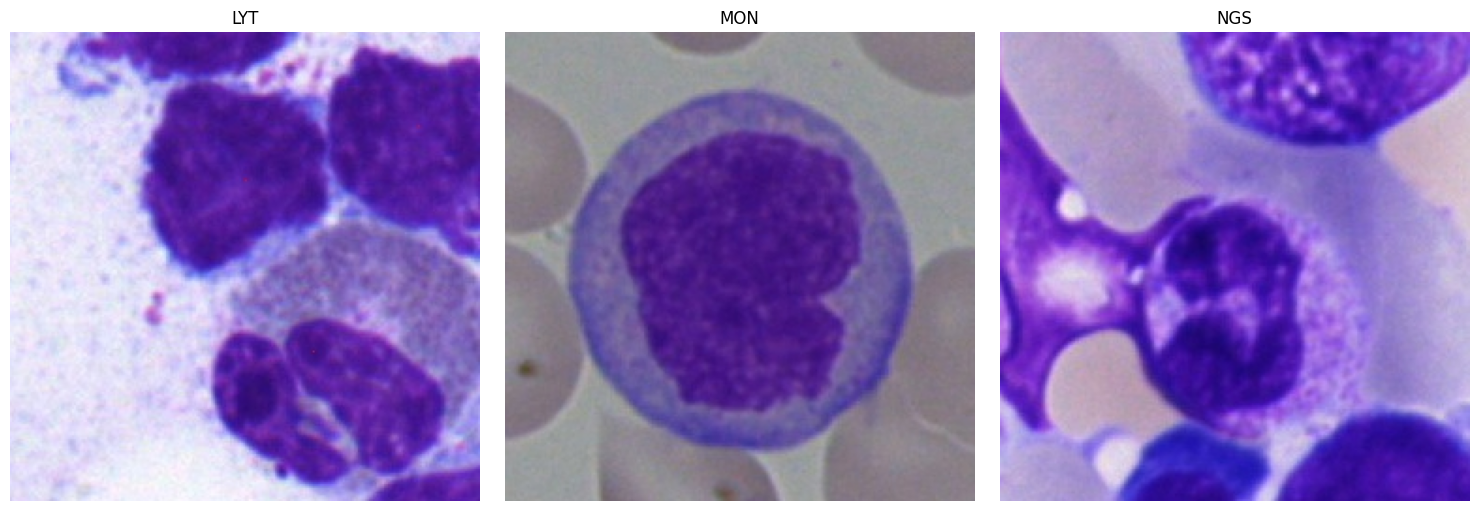

In [6]:
import os
import cv2
import matplotlib.pyplot as plt

train_path = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/dataset/train"

classes = sorted(os.listdir(train_path))

plt.figure(figsize=(15,5))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(train_path, cls))[0]
    img_path = os.path.join(train_path, cls, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.savefig("Figure_4_2_Sample_Images.png")
plt.show()

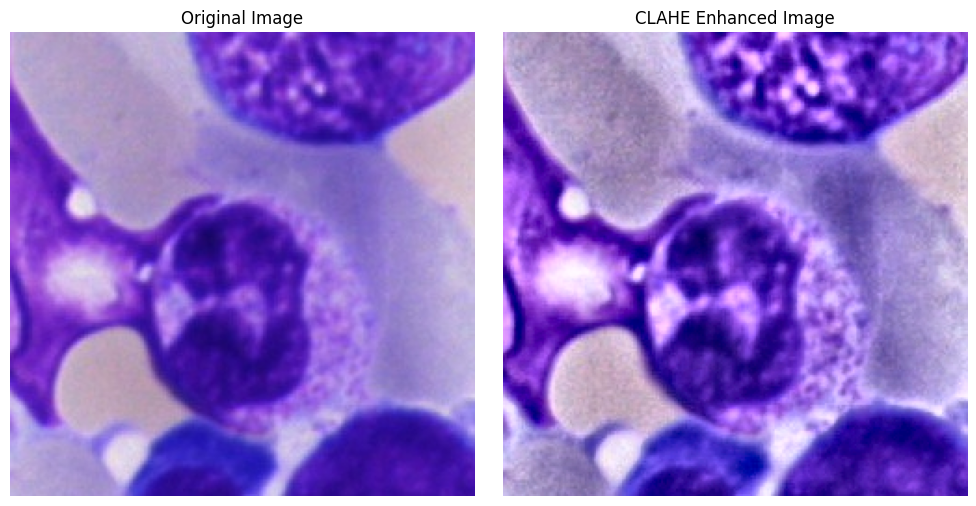

In [7]:
import cv2
import matplotlib.pyplot as plt

sample_image = img_path   # Uses image from previous cell

img = cv2.imread(sample_image)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l_clahe = clahe.apply(l)

enhanced = cv2.merge((l_clahe, a, b))
enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced)
plt.title("CLAHE Enhanced Image")
plt.axis("off")

plt.tight_layout()
plt.savefig("Figure_4_3_CLAHE_Comparison.png")
plt.show()